In [1]:
# 단순선형 회귀 실습 예제

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 데이터 설정
data = {
	'공부시간' : [2, 4, 6, 8, 10],
	'시험점수' : [40, 55, 75, 90, 95]
}

df = pd.DataFrame(data)
print(df)

   공부시간  시험점수
0     2    40
1     4    55
2     6    75
3     8    90
4    10    95


In [3]:
# 독립 변수
X = df[['공부시간']]
# X = df.iloc[:, :-1] # 행은 모두 선택. 열은 0번지부터 마지막전까지
# 종속 변수 => 독립변수에 영향을 받음
y = df[['시험점수']]
# y = df.iloc[:, :-1] # 행은 모두 선택. 열은 마지막부터 끝까지
print(X)
print(y)


   공부시간
0     2
1     4
2     6
3     8
4    10
   시험점수
0    40
1    55
2    75
3    90
4    95


In [ ]:
# 데이터 분리(훈련테스트와 테스트데이터로 분리)
# test_size = 0.2 테스트 데이터를 전체의 20%로 선정
# 테스트 데이터와 훈련 데이터를 랜덤으로 선택
# random_state를 고정으로 하면 매번 선택되는 테스트 데이터와 훈련 데이터가 같음
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # train_test_split: scikit-learn에서 제공하는 도구. 데이터 분할 / 셔플 / 결과 고정
# train_test_split 함수는 내부적으로 다음과 같은 규칙을 가지고 있습니다.
# "첫 번째로 넣어준 놈(X)을 쪼개서 앞의 두 자리에 주고, 두 번째로 넣어준 놈(y)을 쪼개서 뒤의 두 자리에 준다!"
# 첫 번째 자리의 첫 번째 자리는 모델이 학습할 때 사용하는 데이터 / 첫 번째 자리의 두 번째 데이터는 성능을 평가할 때 사용하는 데이터(학습할 때 사용하지 않은 데이터. 한 번도 본 적 없는 문제를 푸는 것)
# [1번 자리], [2번 자리], [3번 자리], [4번 자리] = train_test_split(X, y)
# => 1번 자리: 전체 문제 중에서 공부용으로 떼어놓은 문제들
# 2번 자리: 전체 문제 중에서 시험용으로 숨겨놓은 문제들
# 3번 자리: 1번 문제들에 대한 공부용 정답
# 4번 자리: 2번 문제들에 대한 시험용 정답

In [ ]:
model = LinearRegression() # 선형 회귀 모델 선택
model.fit(X_train, y_train) # 문제와 답으로 공부하기. 처음에는 아무 숫자(w, b)나 넣어서 결과를 예측해보고 y_train을 보고 정답을 확인하고 오차를 줄이기 위해 기울기와 절편을 조금씩 수정한다.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 테스트 데이터로 예측
y_pred = model.predict(X_test) #새로운 문제 풀고 답안지 작성. ai가 공부한 내용을 바탕으로 "한 번도 본 적 없는 문제에 대해 답을 써내는 순간 => 공식을 찾는다."
print(f"테스트 종속변수 : {X_test['공부시간'].values}") # "이제 ai에게 시험 치게 할건데, 그 시험 문제지에 적인 '공부시간'들이 구체적으로 몇시간들이었는지 리스트로 보여줘"
print(f"실제값: {y_test.values}")
print(f"예측값: {y_pred}")

테스트 종속변수 : [4]
실제값: [[55]]
예측값: [[57.14285714]]


In [11]:
print(f'가중치(w) : {model.coef_}')
print(f'절편(b){model.intercept_}')

가중치(w) : [[7.14285714]]
절편(b)[28.57142857]


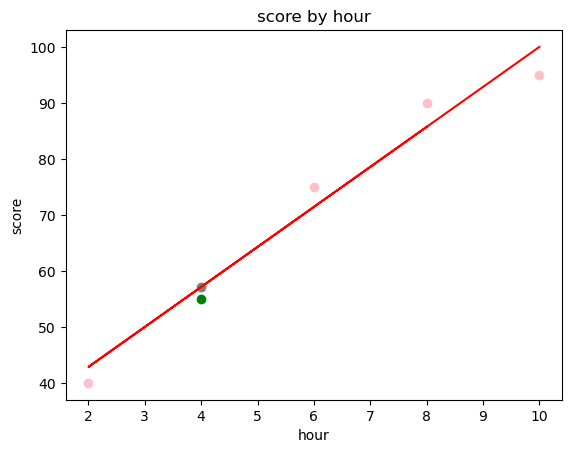

In [ ]:
plt.scatter(X_train, y_train, color='pink') # 훈련 데이터를 점으로 출력
plt.plot(X_train, model.predict(X_train), color='red') # 학습을 통해 나온 직선
plt.scatter(X_test, model.predict(X_test), color='gray') # 테스트 데이터의 예측 데이터
plt.scatter(X_test, y_test, color='green')  # 테스트 데이터의 실제 데이터
plt.title('score by hour') # 그래프 제목
plt.xlabel('hour') # x축 => 보통 독립변수
plt.ylabel('score') # y축 => 보통 종속변수
plt.show() # 그래프 출력

In [16]:
# 모델 평가
print(model.score(X_test, y_test))

nan


c:\Users\hi6\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

NameError: name 'mean_absolute_error' is not defined